# Pivot dataframe: long -> wide tables
## Example 1: patent data

Here I am using a data from my research [linked here](https://www.nature.com/articles/s41599-025-06038-6).

The data contains the following columns:
- filing_year: the years of patent filing, 1976-2021
- gender_collab_type: a categorical variable indicating the gender composition of the patent's inventor team. There are three possible values: only_females, only_males, and gender_collab.
- reliance_on_public_funding: a categorical variable whether the patent relies on public funding, such as federal research grants. There are three possible values: Indirect, Direct, and No_support.
- patent_count: the number of patent filed in that year that belong to the two categories specified in `gender_collab_type` and `reliance_on_public_funding`.

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

use_cols = ['filing_year', 'gender_collab_type',
       'gov_reliance_type_three_type', 'patent_count']
df=pd.read_csv("../07-Data_visualization/data/time_series_three_gov_support_by_gender_collab_type_20250624.csv", usecols=use_cols,
               dtype={'filing_year': int, "patent_count": int}).rename(columns={"gov_reliance_type_three_type":"reliance_on_public_funding"})

df

,filing_year,gender_collab_type,reliance_on_public_funding,patent_count
0,1981,gender_collab,Indirect,126
1,2009,only_females,Direct,118
2,2008,only_females,Indirect,473
3,1984,gender_collab,No_support,1428
4,1989,only_females,Indirect,118
...,...,...,...,...
385,1983,gender_collab,No_support,1262
386,2005,gender_collab,Indirect,3646
387,1976,gender_collab,Indirect,104
388,2015,only_females,Direct,69


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390 entries, 0 to 389
Data columns (total 4 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   filing_year                 390 non-null    int64 
 1   gender_collab_type          390 non-null    object
 2   reliance_on_public_funding  390 non-null    object
 3   patent_count                390 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 12.3+ KB


### Basic Pivot Table (Single Dimension)

Goal: Total patent counts by gender collaboration type
- `index`: rows
- `values`: what we aggregate
- `aggfunc="sum"`: total patents

In [19]:
pivot_1 = pd.pivot_table(
    data=df,
    values="patent_count",
    index="gender_collab_type",
    aggfunc="sum"
)

pivot_1

,patent_count
gender_collab_type,
gender_collab,551785
only_females,99542
only_males,3045544


Above cell is actually equivalent to `df.groupby("gender_collab_type")['patent_count'].sum()`.

### Two-Dimensional Pivot
Compare gender collaboration × government reliance

- Adds columns dimension
- Creates a matrix (like contingency table but with values)


In [23]:
pivot_2 = pd.pivot_table(
    data=df,
    values="patent_count",
    index="gender_collab_type",
    columns="reliance_on_public_funding",
    aggfunc="sum"
)

print(pivot_2)

reliance_on_public_funding  Direct  Indirect  No_support
gender_collab_type                                      
gender_collab                27344     85586      438855
only_females                  2867     10906       85769
only_males                   96254    431921     2517369


Above cell is equivalent to `pd.crosstab(df['gender_collab_type'], df['reliance_on_public_funding'], values=df['patent_count'], aggfunc='sum')`

### Add Time Dimension (Multi-Index)

In [28]:
pivot_3 = pd.pivot_table(
    df,
    values="patent_count",
    index=["filing_year", "gender_collab_type"],
    columns="reliance_on_public_funding",
    aggfunc="sum"
)

print(pivot_3)

reliance_on_public_funding      Direct  Indirect  No_support
filing_year gender_collab_type                              
1976        gender_collab         76.0     104.0      1224.0
            only_females          18.0      56.0       784.0
            only_males          1772.0    3553.0     44226.0
1977        gender_collab         88.0      75.0      1045.0
            only_females          18.0      57.0       691.0
...                                ...       ...         ...
2020        only_females           NaN       NaN      3392.0
            only_males             NaN       NaN     89022.0
2021        gender_collab          NaN       NaN     21398.0
            only_females           NaN       NaN      2794.0
            only_males             NaN       NaN     69558.0

[138 rows x 3 columns]


Or if we are only interested in the number of patents filed by teams of different gender composition regardless of their funding situation:

In [32]:
pivot_3_alt = pd.pivot_table(
    df,
    values="patent_count",
    index="filing_year",
    columns="gender_collab_type",
    aggfunc="sum"
)

print(pivot_3_alt.head())

gender_collab_type  gender_collab  only_females  only_males
filing_year                                                
1976                         1404           858       49551
1977                         1208           766       40198
1978                         1100           765       37661
1979                         1167           777       36965
1980                         1272           731       36857


Or only interested in the reliance on public funding, regardless of their gender composition

In [33]:
pivot_3_alt_1 = pd.pivot_table(
    df,
    values="patent_count",
    index="filing_year",
    columns="reliance_on_public_funding",
    aggfunc="sum"
)

print(pivot_3_alt_1.head())

reliance_on_public_funding  Direct  Indirect  No_support
filing_year                                             
1976                        1866.0    3713.0     46234.0
1977                        1760.0    3255.0     37157.0
1978                        1717.0    3419.0     34390.0
1979                        1661.0    3637.0     33611.0
1980                        1734.0    3725.0     33401.0


### Multiple columns to pivot

Goal: if we wanted to pivot the table to a wide table with nine columns, representing the nine groups based on the two categorical variables:

In [38]:
pivot_wide = pd.pivot_table(
    data=df,
    values="patent_count",
    index="filing_year",
    columns=["gender_collab_type","reliance_on_public_funding"],
    aggfunc="sum",
    fill_value=0
)

pivot_wide

gender_collab_type         gender_collab                     only_females  \
reliance_on_public_funding        Direct Indirect No_support       Direct   
filing_year                                                                 
1976                                  76      104       1224           18   
1977                                  88       75       1045           18   
1978                                  78       98        924           16   
1979                                  85      111        971           19   
1980                                  96      112       1064           12   
1981                                  95      126       1082           31   
1982                                 127      188       1198           25   
1983                                 113      187       1262           29   
1984                                 138      249       1428           25   
1985                                 143      273       1636           27   
1986                                 155      354       1776           36   
1987                                 175      374       2161           25   
1988                                 215      475       2558           37   
1989                                 250      543       2864           43   
1990                                 279      571       3302           52   
1991                                 319      693       3598           50   
1992                                 368      783       3855           52   
1993                                 478     1035       4367           58   
1994                                 572     1276       5283           82   
1995                                 829     2268       6698          116   
1996                                 589     1596       6401           70   
1997                                 716     2086       8036           92   
1998                                 794     2215       8097          106   
1999                                 899     2728       9058           93   
2000                                 931     3219       9811          103   
2001                                 953     3586      10478          104   
2002                                1032     4055      10220          103   
2003                                1083     3878       9905           90   
2004                                1029     3719       9911           76   
2005                                1155     3646       9786          101   
2006                                1203     3865       9974          101   
2007                                1329     4267      10918          110   
2008                                1295     3985      11127          122   
2009                                1311     4132      10293          118   
2010                                1367     4455      11145          114   
2011                                1488     4577      12426          121   
2012                                1533     5219      14696          128   
2013                                1554     5423      17068          132   
2014                                1189     4506      18687          113   
2015                                 841     3000      21589           69   
2016                                 338     1360      25521           23   
2017                                  36      174      28363            7   
2018                                   0        0      29004            0   
2019                                   0        0      29998            0   
2020                                   0        0      26649            0   
2021                                   0        0      21398            0   

gender_collab_type                             only_males                      
reliance_on_public_funding Indirect No_support     Direct Indirect No_support  
filing_year                                                       

### Multiple Aggregations
Goal: Compute both sum and mean


In [41]:
pivot_4 = pd.pivot_table(
    df,
    values="patent_count",
    index="gender_collab_type",
    columns="reliance_on_public_funding",
    aggfunc=["sum", "mean"],
    margins=True, # try change it to True and False
)

pivot_4

sum                                      mean  \
reliance_on_public_funding  Direct Indirect No_support      All       Direct   
gender_collab_type                                                             
gender_collab                27344    85586     438855   551785   651.047619   
only_females                  2867    10906      85769    99542    68.261905   
only_males                   96254   431921    2517369  3045544  2291.761905   
All                         126465   528413    3041993  3696871  1003.690476   

                                                                      
reliance_on_public_funding      Indirect    No_support           All  
gender_collab_type                                                    
gender_collab                2037.761905   9540.326087   4244.500000  
only_females                  259.666667   1864.543478    765.707692  
only_males                  10283.833333  54725.413043  23427.261538  
All                          4193.753968  22043.427536   9479.156410

### Normalize (Share within Group)
Goal: Convert counts into proportions

In [51]:
pivot = pd.pivot_table(
    df,
    values="patent_count",
    index="gender_collab_type",
    columns="reliance_on_public_funding",
    aggfunc="sum",
    margins=False, # if set it as True, it will take half of the value (proportion)
)

pivot

reliance_on_public_funding,Direct,Indirect,No_support
gender_collab_type,,,
gender_collab,27344,85586,438855
only_females,2867,10906,85769
only_males,96254,431921,2517369


In [52]:
# Normalize row-wise
pivot_norm_row_wise = pivot.div(pivot.sum(axis=1), axis=0)

# Normalize col-wise
pivot_norm_col_wise = pivot.div(pivot.sum(axis=0), axis=1)

print("Pivot table (normalized row-wise):")
print(pivot_norm_row_wise)


print("\nPivot table (normalized column-wise):")
print(pivot_norm_col_wise)

Pivot table (normalized row-wise):
reliance_on_public_funding    Direct  Indirect  No_support
gender_collab_type                                        
gender_collab               0.049556  0.155108    0.795337
only_females                0.028802  0.109562    0.861636
only_males                  0.031605  0.141821    0.826574

Pivot table (normalized column-wise):
reliance_on_public_funding    Direct  Indirect  No_support
gender_collab_type                                        
gender_collab               0.216218  0.161968    0.144266
only_females                0.022670  0.020639    0.028195
only_males                  0.761112  0.817393    0.827539


## Example 2: Stony Brook temperature

In [59]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../07-Data_visualization/data/stony_brook_daily_temperature_2025.csv")

# Convert Celsius → Fahrenheit
df["temp_F"] = df["average_temperature"] * 9/5 + 32

df

,month,day,average_temperature,temp_F
0,1,1,7.5,45.50
1,1,2,3.3,37.94
2,1,3,0.6,33.08
3,1,4,-1.5,29.30
4,1,5,-2.3,27.86
...,...,...,...,...
360,12,27,-3.3,26.06
361,12,28,-2.8,26.96
362,12,29,5.8,42.44
363,12,30,-1.2,29.84


In [60]:
df.columns


Index(['month', 'day', 'average_temperature', 'temp_F'], dtype='object')

#### Average Temperature by Month

In [61]:
pivot_1 = pd.pivot_table(
    df,
    values="temp_F",
    index="month",
    aggfunc="mean"
)

print(pivot_1)

          temp_F
month           
1      29.886452
2      32.559286
3      43.479355
4      51.092000
5      59.632903
6      70.028000
7      75.908387
8      70.601290
9      67.292000
10     57.101290
11     46.238000
12     33.260000


#### Day × Month Matrix (Temperature Table)

In [72]:
pivot_2 = pd.pivot_table(
    df,
    values="temp_F",
    index="day",
    columns="month",
    aggfunc="mean"
)

pivot_2

month,1,2,3,4,5,6,7,8,9,10,11,12
day,,,,,,,,,,,,
1,45.50,35.06,43.88,47.48,59.18,54.86,76.82,64.22,66.20,60.80,51.08,39.02
2,37.94,21.20,24.08,39.56,63.14,59.54,73.58,69.08,66.56,57.74,49.28,37.58
3,33.08,37.04,23.72,49.64,65.66,65.48,75.56,71.42,66.02,60.08,54.50,34.34
4,29.30,38.84,36.86,62.78,62.42,68.54,69.98,73.76,67.82,65.84,51.44,35.60
5,27.86,27.14,48.02,49.46,59.72,73.58,73.94,74.66,71.60,72.14,54.68,24.08
6,27.86,31.28,48.56,43.70,59.90,73.40,75.38,70.52,72.68,68.54,50.54,36.68
7,22.64,36.50,36.50,42.26,61.88,69.80,76.10,70.52,61.52,67.82,47.84,37.94
8,23.90,28.76,38.66,38.30,66.20,65.30,79.34,70.16,62.78,65.48,57.38,29.84
9,24.62,29.66,37.22,34.52,57.56,60.08,77.36,70.70,64.22,54.68,56.84,23.90


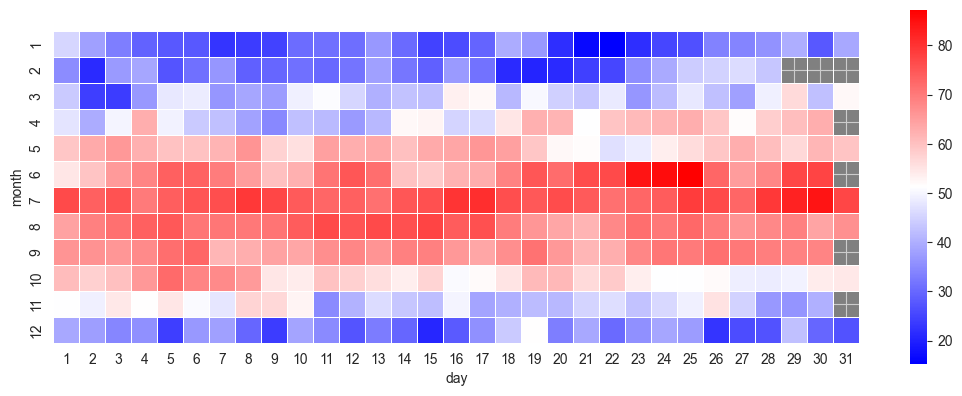

In [103]:
# we can create a heatmap using this matrix

fig, ax = plt.subplots(1, 1, figsize=(13, 4.6))

sns.heatmap(pivot_2.T, ax=ax, cmap="bwr", linewidths=.4, square=True)

ax.set_facecolor('grey')

#### Max Temperature by Month

In [65]:
pivot_3 = pd.pivot_table(
    df,
    values="temp_F",
    index="month",
    aggfunc="max"
)

pivot_3

,temp_F
month,
1,45.50
2,46.22
3,56.48
4,62.78
5,66.20
6,87.26
7,84.38
8,77.54
9,72.68


#### Add “Temperature Category” and Pivot

In [71]:
# Create temperature categories
df["temp_category"] = pd.cut(
    df["temp_F"],
    bins=[0, 40, 60, 80, 100],
    labels=["Cold", "Mild", "Warm", "Hot"]
)

pivot_5 = pd.pivot_table(
    df,
    values="temp_F",
    index="month",
    columns="temp_category",
    aggfunc="count",
    fill_value=0,
    observed=True
)

print(pivot_5)

temp_category  Cold  Mild  Warm  Hot
month                               
1                30     1     0    0
2                24     4     0    0
3                 8    23     0    0
4                 4    18     8    0
5                 0    15    16    0
6                 0     4    23    3
7                 0     0    28    3
8                 0     0    31    0
9                 0     0    30    0
10                0    22     9    0
11                4    26     0    0
12               28     3     0    0
